# physprior: summary of results

This project asks what a physics prior buys a machine-learning model, and what
it costs when the law is wrong. Models that know a law (a fitted law, a
physics-informed network, symbolic regression) are compared with a tuned black
box on the same splits. The comparison runs on real measurements and on
simulations whose truth is known, so each method's own error can be told apart
from a flaw in the law.

In [1]:
import os, warnings
warnings.filterwarnings("ignore")
# nothing here runs symbolic regression, so skip the Julia bootstrap
os.environ.setdefault("PHYSPRIOR_NO_JULIA", "1")
import matplotlib.pyplot as plt
from physprior.viz import plots as P
from physprior.reporting import summary as S
P.use_style()

## Method

The arms:

| arm | what it is |
|---|---|
| `oracle` | the published law with published constants; a reference, not a competitor |
| `physics` | the law with its constants fitted, with error bars |
| `pinn` | the law plus a learned correction (or an ODE residual), constants trainable |
| `sr` | symbolic regression, given no law |
| `nn` | a tuned multilayer perceptron, given no law |

The PINN comes in two shapes. Where the law is a differential equation, the
network is the solution and the law enters as a residual (A). Where the law is
algebraic, the network is a correction added to the law and penalised toward
zero (B).

![the two PINN shapes](../figures/summary/pinn_anatomy.png)

The physics weight `w_phys` sets how strongly the correction is held to zero.
It is chosen per track on the tuning seeds, from a validation block at the top
of the training range, with ties going to the larger weight. Loss balancing,
which annealed the weight upward until the PINN reduced to the fitted law, was
removed from the default ([DECISIONS.md](../docs/DECISIONS.md)).

Protocol:

- every choice is tuned on seeds 3, 7, 19; every reported number is on seeds 11, 23, 42;
- the predictions for each study were written before its runs ([HYPOTHESES.md](../docs/HYPOTHESES.md));
- every number in this notebook is read from `results/` when it runs; none is typed.

## Choose a task

Edit `TASK` and re-run the cell to see one task's data, result and conclusion.

Lorenz-63: a PINN against a black box on a chaotic system


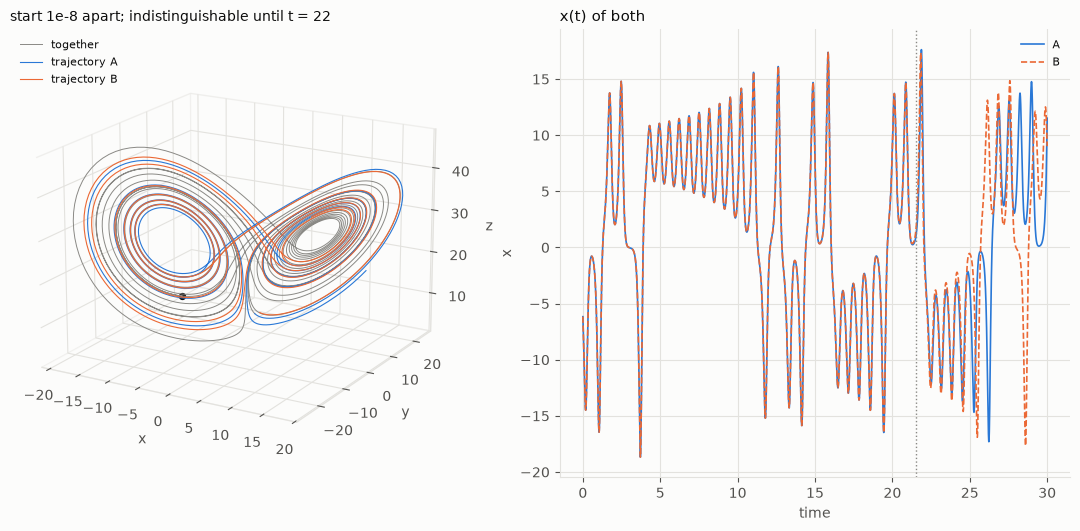

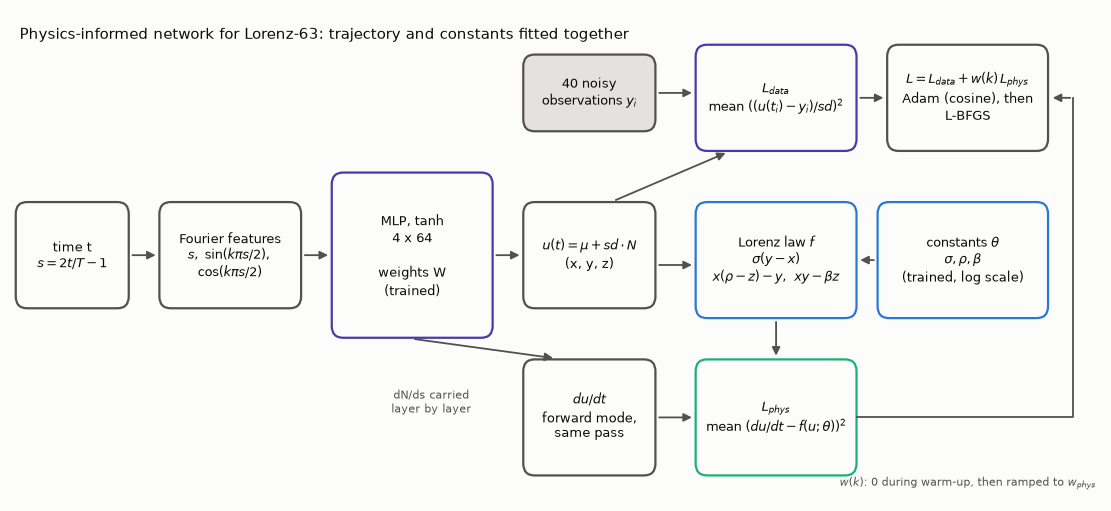

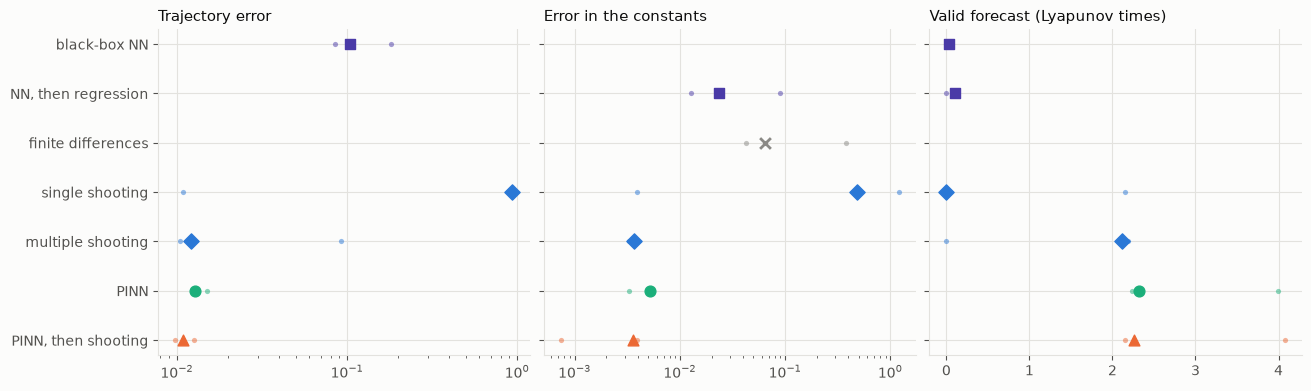

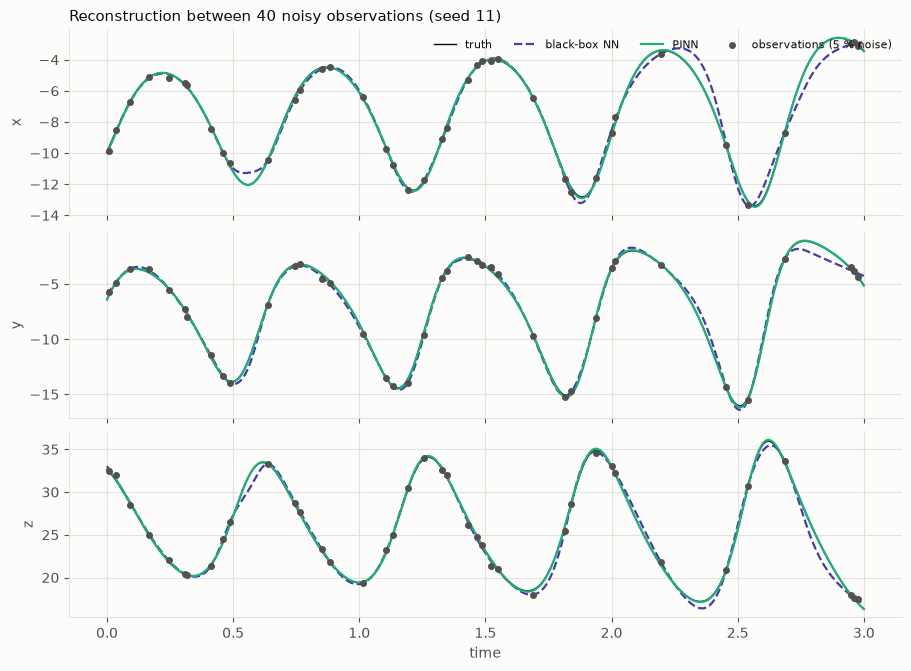

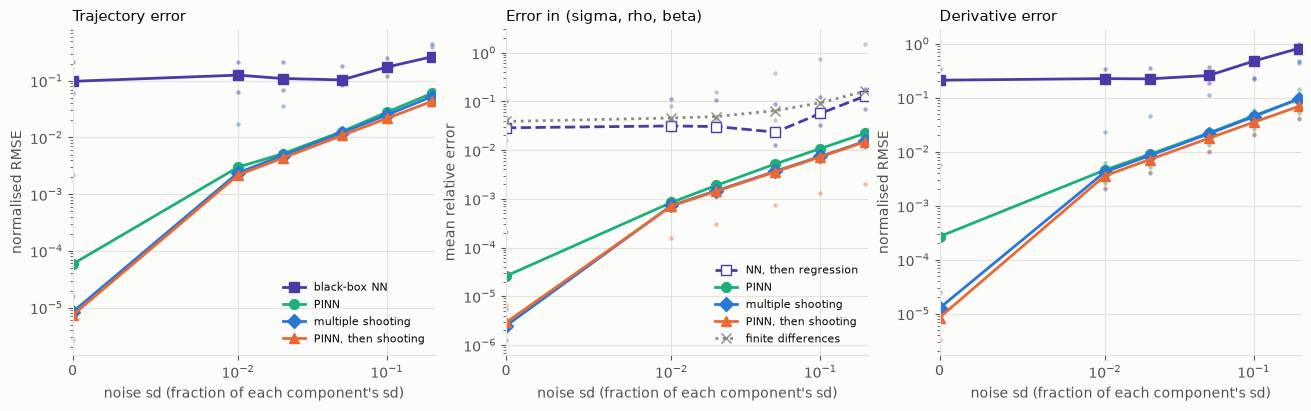

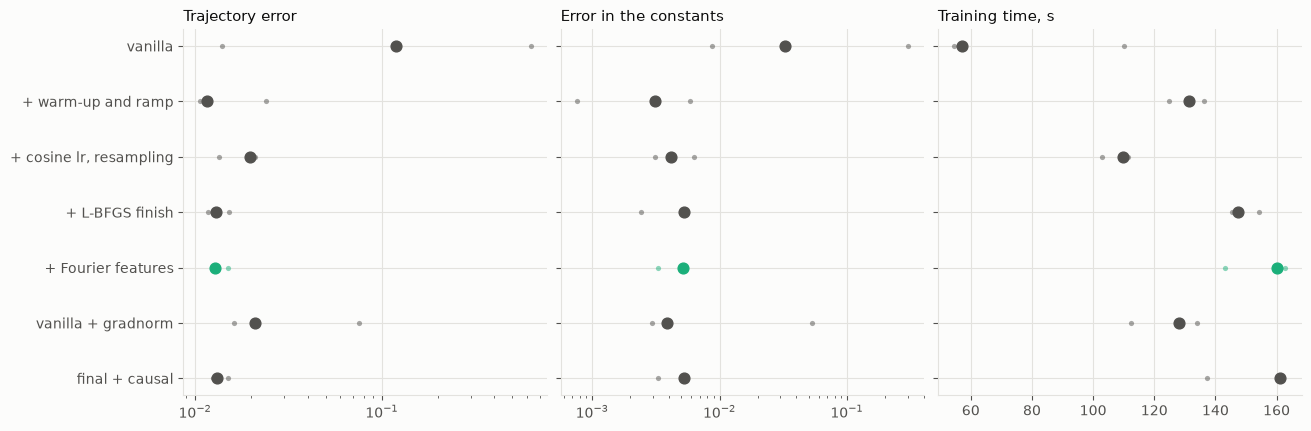

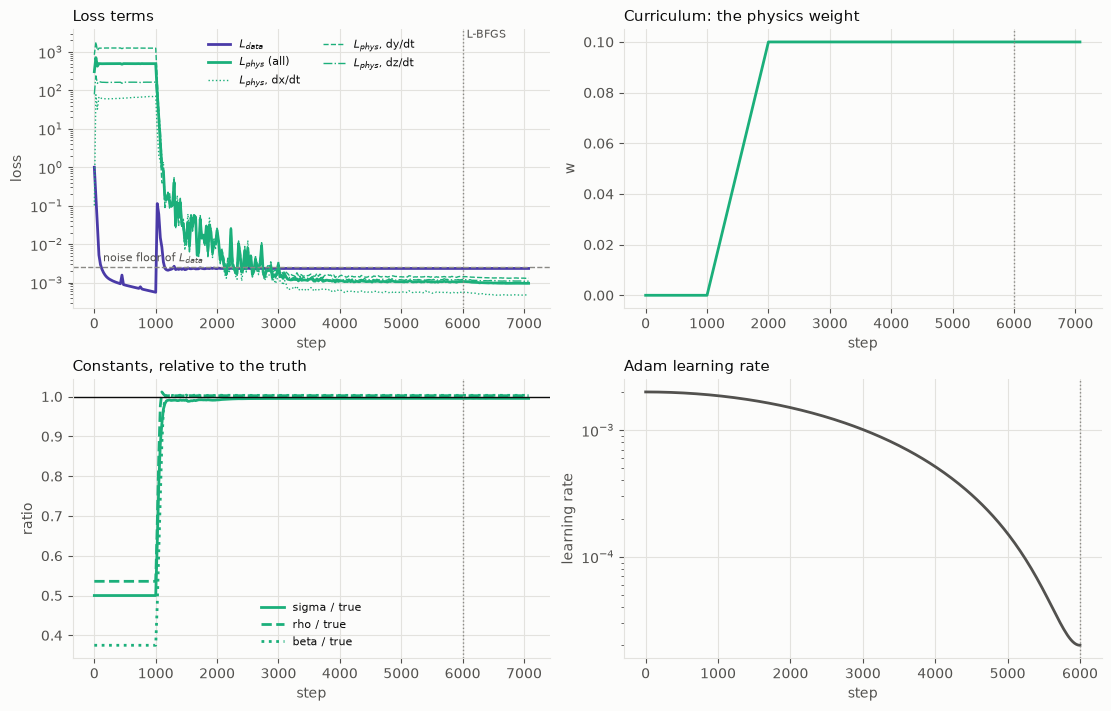

The PINN reconstructs the chaotic trajectory 8.1x more accurately than the tuned black box (3/3 seeds) and recovers (sigma, rho, beta) to 0.52% from a start wrong by a factor of two. Single shooting from that start fails (48%); multiple shooting matches the PINN (0.37%), but with 10 observations only the PINN still does (1.5% against 36%). The training recipe is what makes it work: the vanilla PINN fails on 2 of 3 seeds.


In [2]:
TASK = "lorenz"  # one of: lorenz, gw150914, neglected, pulsars, reconstruction, dynamics, weather, constants, data_budget
S.show(TASK)

## Results by task

Each section shows the data, then the result, then a one-line conclusion computed from `results/`.

## a. Lorenz-63: a PINN against a black box on a chaotic system

Forty noisy observations of one chaotic trajectory. Reconstruct it, recover sigma, rho and beta from a start wrong by a factor of two, and forecast. Below: the butterfly effect, the PINN as a block diagram, every method, the noise sweep, the optimisation ladder and the loss term by term. Details: [docs/lorenz/README.md](../docs/lorenz/README.md).

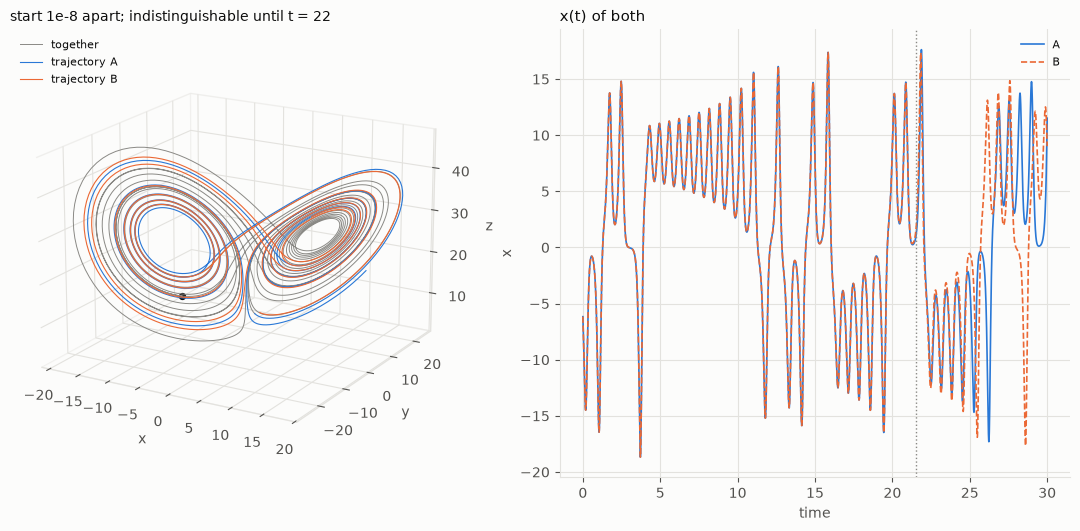

In [3]:
S.lorenz_data();

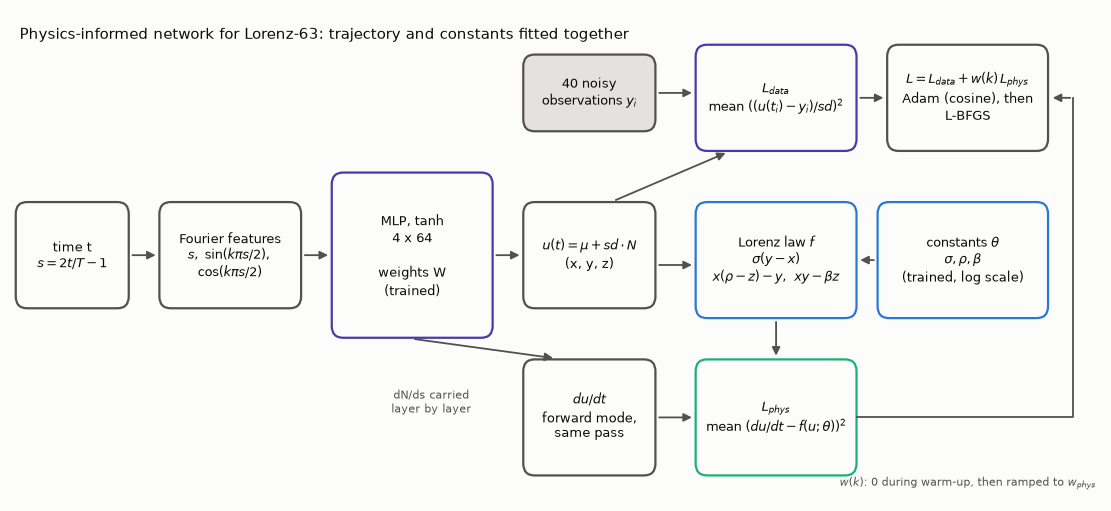

In [4]:
S.lorenz_method();

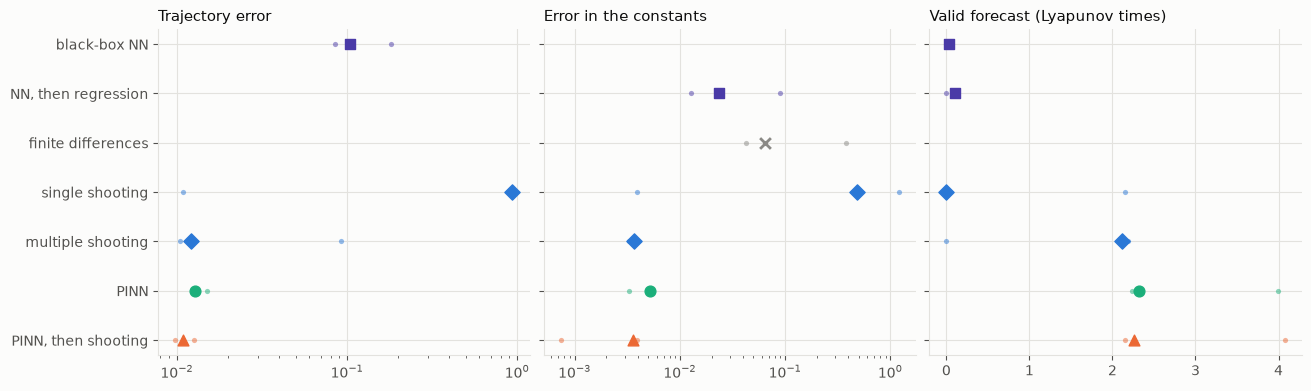

In [5]:
S.lorenz_result();

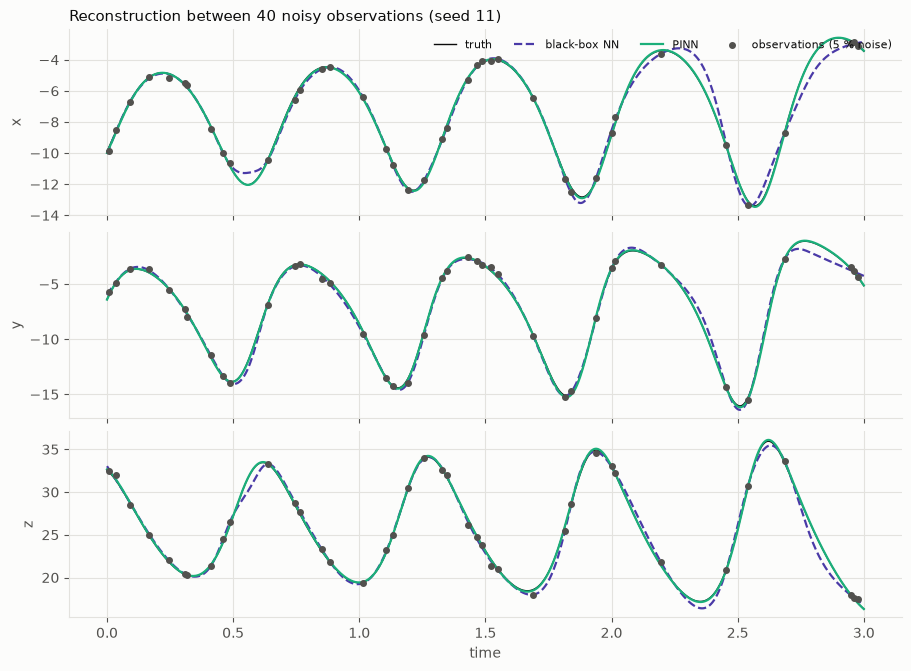

In [6]:
S.lorenz_reconstruction();

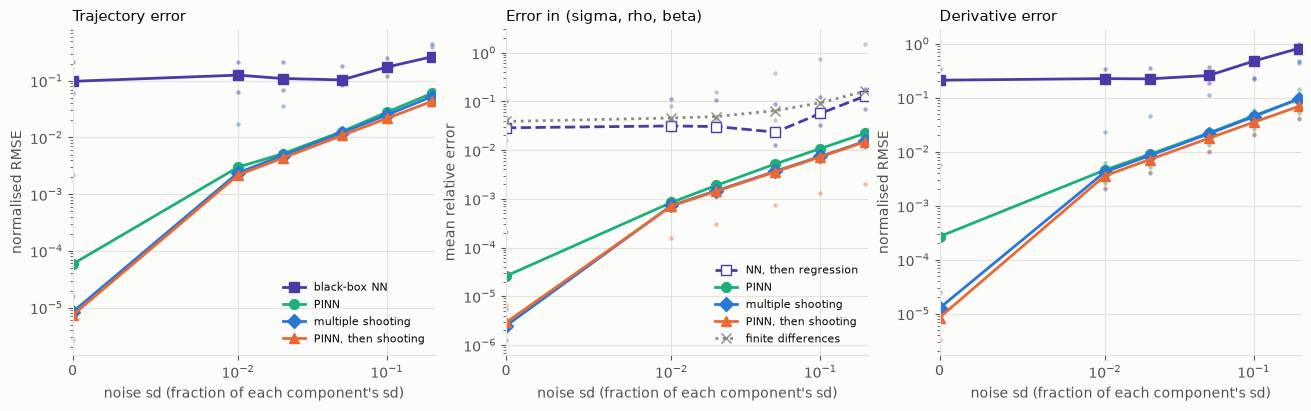

In [7]:
S.lorenz_noise();

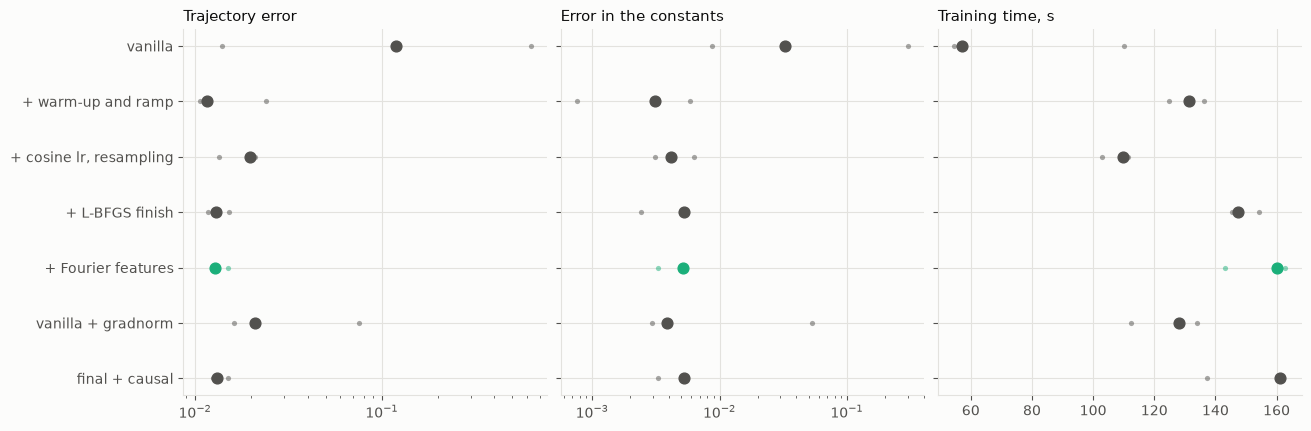

In [8]:
S.lorenz_ladder();

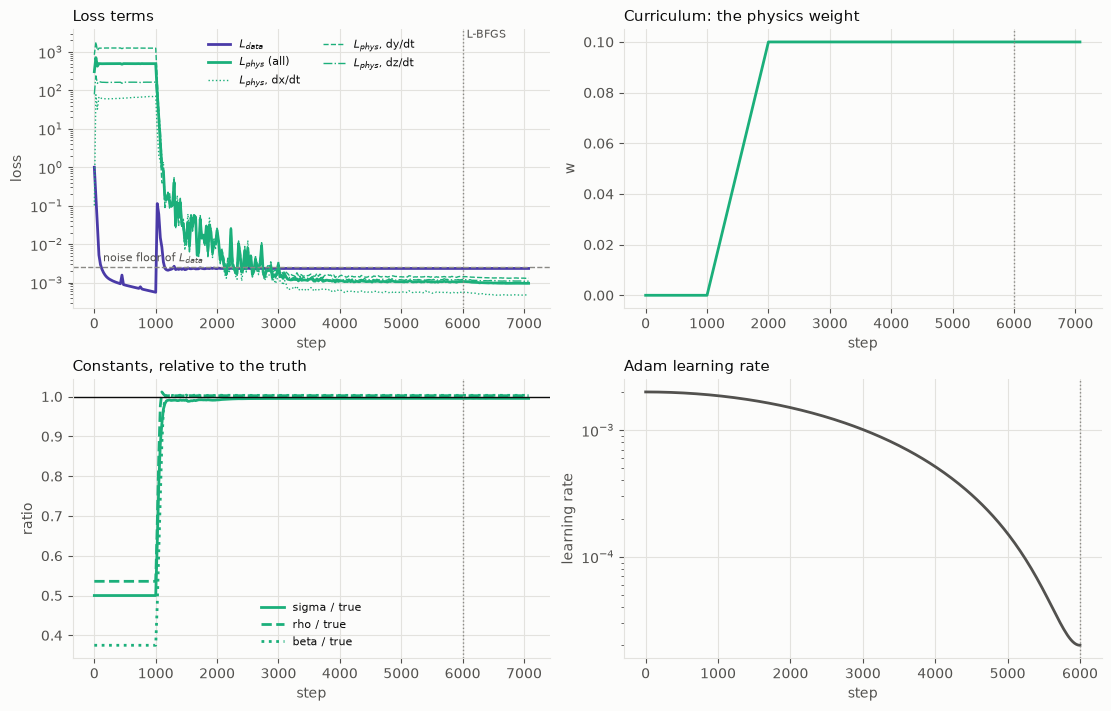

In [9]:
S.lorenz_loss();

In [10]:
print(S.lorenz_conclusion())

The PINN reconstructs the chaotic trajectory 8.1x more accurately than the tuned black box (3/3 seeds) and recovers (sigma, rho, beta) to 0.52% from a start wrong by a factor of two. Single shooting from that start fails (48%); multiple shooting matches the PINN (0.37%), but with 10 observations only the PINN still does (1.5% against 36%). The training recipe is what makes it work: the vanilla PINN fails on 2 of 3 seeds.


## b. Extrapolating the GW150914 chirp

Six cycles of the frequency track of LIGO's first detection. Train on the earlier cycles, predict the later ones, where the frequency rises fastest. Details: [docs/relativity/README.md](../docs/relativity/README.md).

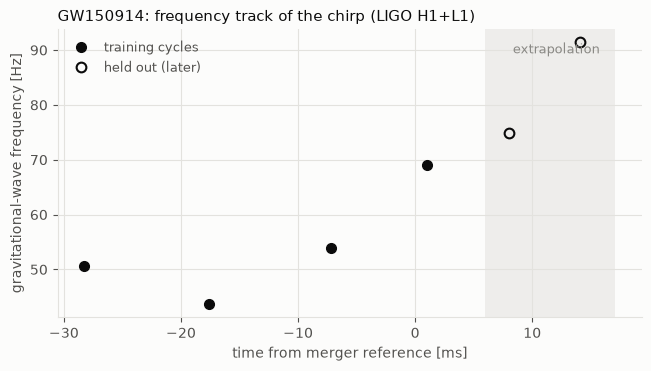

In [11]:
S.gw150914_data();

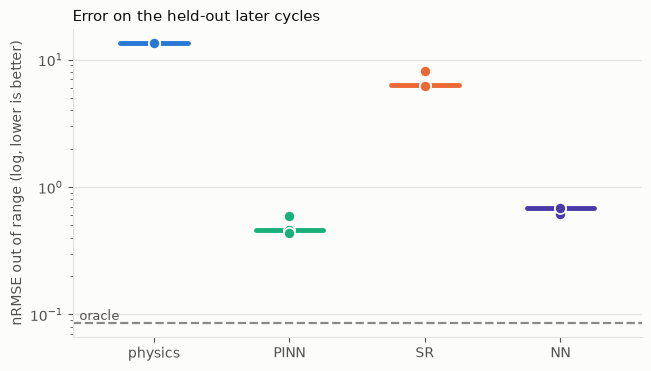

In [12]:
S.gw150914_result();

In [13]:
print(S.gw150914_conclusion())

Best extrapolation: PINN. Median nRMSE out of range: physics 13.45, PINN 0.46, SR 6.36, NN 0.68; the ODE-residual PINN beats the fitted law on 3/3 seeds.


## c. When a law with a missing term still helps

Simulations where the truth is a law plus a term the model does not contain. Here a pendulum whose damping the law leaves out. Details: [docs/neglected/README.md](../docs/neglected/README.md).

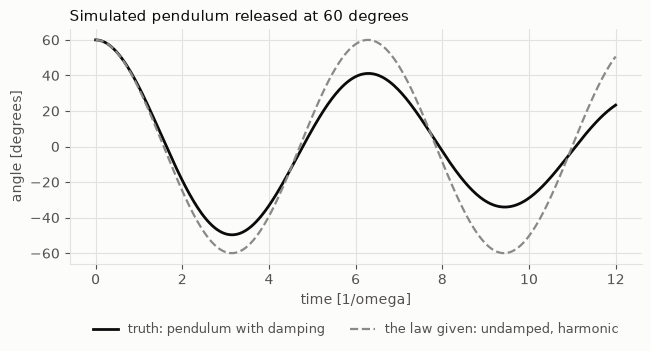

In [14]:
S.neglected_data();

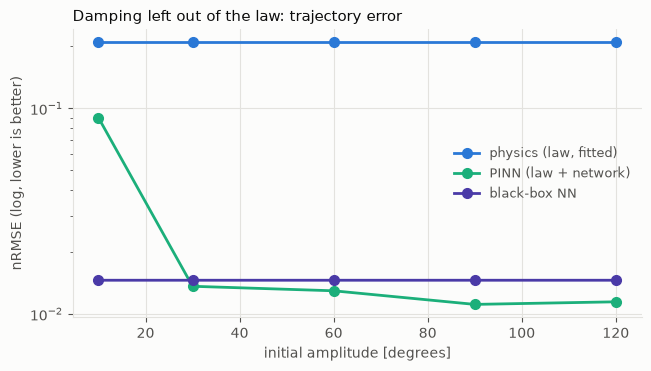

In [15]:
S.neglected_result();

In [16]:
print(S.neglected_conclusion())

With damping left out, the PINN beats both physics and NN at 4/5 amplitudes (at 60 deg: PINN 0.013, NN 0.015, physics 0.21); when the missing term is shaped like the law (anharmonic), physics is best at 3/5.


## d. Pulsar braking index

The magnetic-dipole law predicts n = 3 for every pulsar. Test it on the measured young pulsars, then check on a simulated control whose n falls with age that the PINN could learn such a dependence. Details: [docs/gravity/README.md](../docs/gravity/README.md).

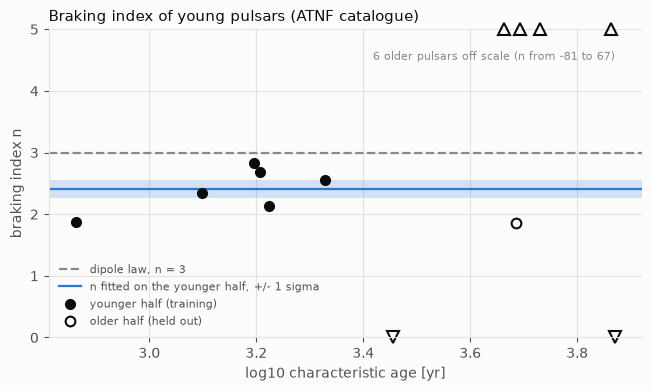

In [17]:
S.pulsars_data();

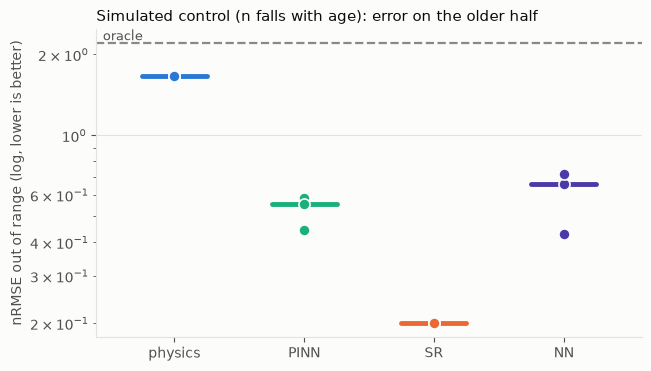

In [18]:
S.pulsars_result();

In [19]:
print(S.pulsars_conclusion())

Real pulsars: n = 2.40 +/- 0.15, 4.1 sigma below 3, so the dipole law is incomplete. Control: the PINN learns the age dependence (nRMSE 0.56 against physics 1.67, better on 3/3 seeds); best arm SR (0.20).


## e. Reconstructing a field from sparse sensors in 1-D, 2-D and 3-D

A Poisson field from three sources, sampled by N noisy sensors. How many sensors does each method need as the dimension grows? Details: [docs/reconstruction/README.md](../docs/reconstruction/README.md).

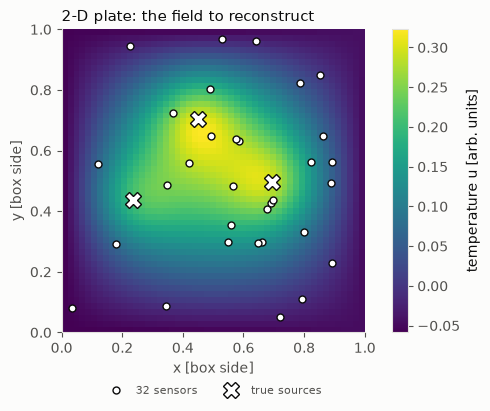

In [20]:
S.reconstruction_data();

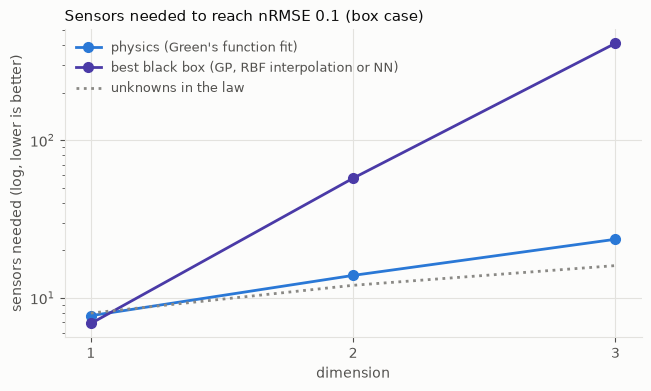

In [21]:
S.reconstruction_result();

In [22]:
print(S.reconstruction_conclusion())

Sensors for nRMSE 0.1 in 1-D/2-D/3-D -- box: physics 8/14/24, best black box 7/57/411; free: physics 9/11/17, best black box 8/41/332. The physics fit grows with the number of unknowns, the black boxes by about a decade per dimension.


## f. Learning the update rule of a dynamical system

A stepper learns u(t + dt) from pairs of states and is then iterated far beyond its training trajectories. Details: [docs/dynamics/README.md](../docs/dynamics/README.md).

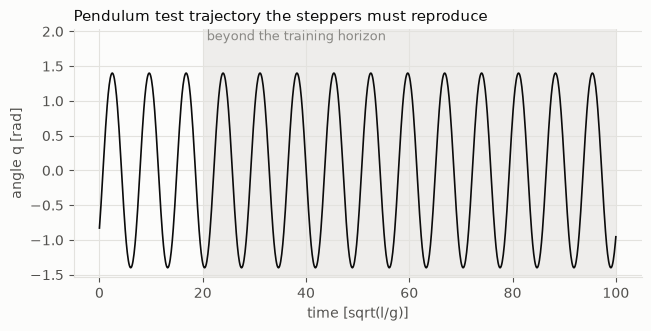

In [23]:
S.dynamics_data();

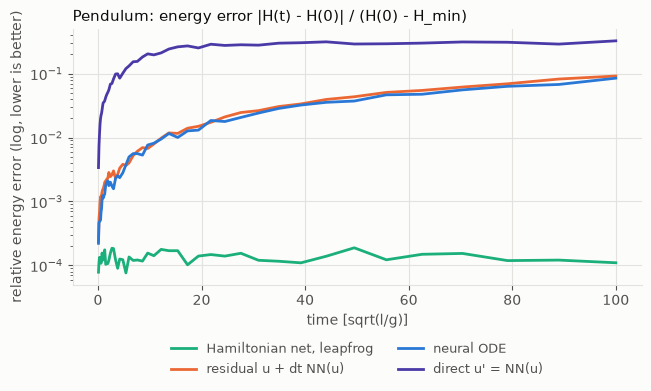

In [24]:
S.dynamics_result_energy();

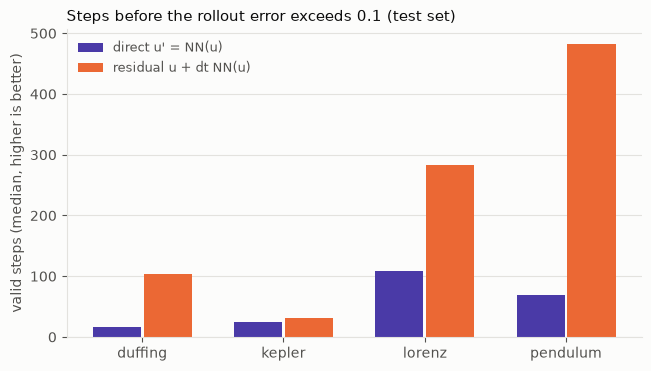

In [25]:
S.dynamics_result_horizon();

In [26]:
print(S.dynamics_conclusion())

Pendulum energy error late in the rollout: leapfrog HNN 1.5e-04, against 7.7e-02 to 3.1e-01 for the black boxes; the residual stepper stays valid a median 4.3x longer than the direct one (4/4 systems).


## g. Temperature over the Alps

July mean temperature at weather stations. Train on the low stations, predict the high ones, and read off the lapse rate. Details: [docs/fields/weather.md](../docs/fields/weather.md).

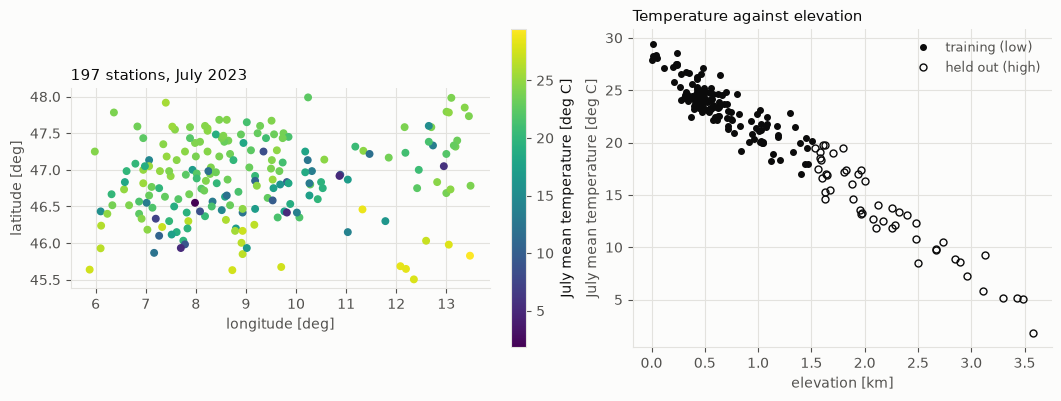

In [27]:
S.weather_data();

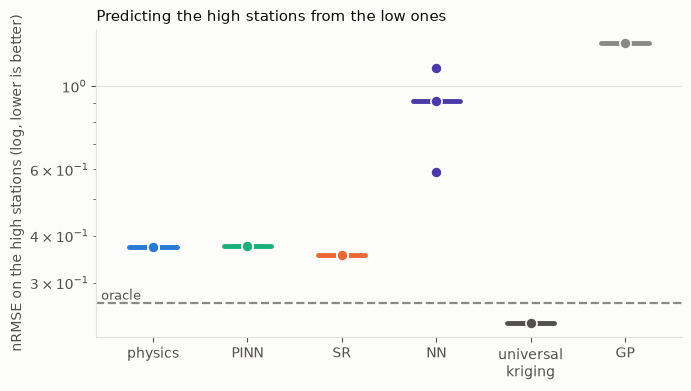

In [28]:
S.weather_result();

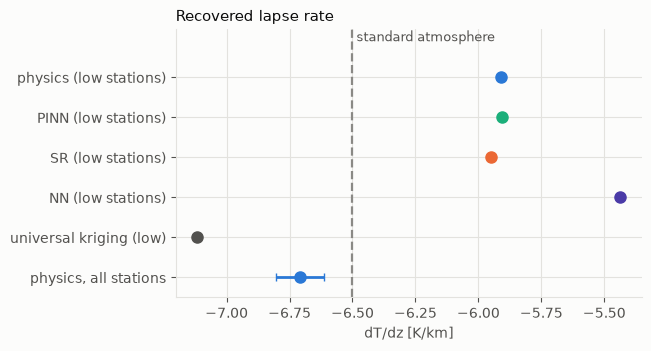

In [29]:
S.weather_lapse();

In [30]:
print(S.weather_conclusion())

Trained below 1.5 km, nRMSE on the high stations: universal kriging 0.23, SR 0.36, physics 0.37, PINN 0.38, NN 0.91; lapse rate from all stations -6.71 +/- 0.10 K/km against -6.5 (-2.1 sigma).


## h. Constants recovered by the physics arm

The fitted law returns a constant with an error bar, which can be compared with the published value. Details: [docs/RESULTS.md](../docs/RESULTS.md).

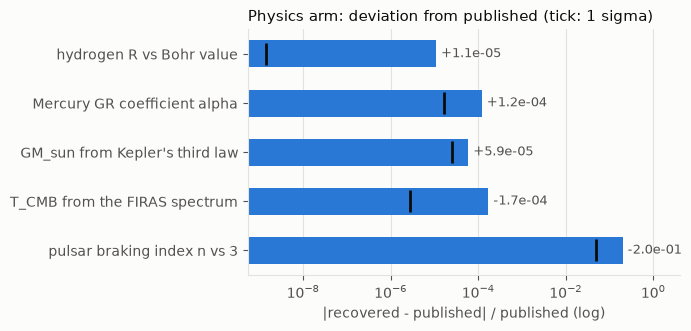

In [31]:
S.constants_result();

In [32]:
print(S.constants_conclusion())

Relative deviation (fit sigmas): hydrogen R vs Bohr value +1.1e-05 (+7784.5 sigma); Mercury GR coefficient alpha +1.2e-04 (+7.3 sigma); GM_sun from Kepler's third law +5.9e-05 (+2.3 sigma); T_CMB from the FIRAS spectrum -1.7e-04 (-61.3 sigma) (partly by construction); pulsar braking index n vs 3 -2.0e-01 (-4.1 sigma).


## i. The amount of training data (H7)

Error against training-set size on five tracks, with the PINN's physics weight either fixed per track or chosen again for each size. Details: [docs/HYPOTHESES.md](../docs/HYPOTHESES.md).

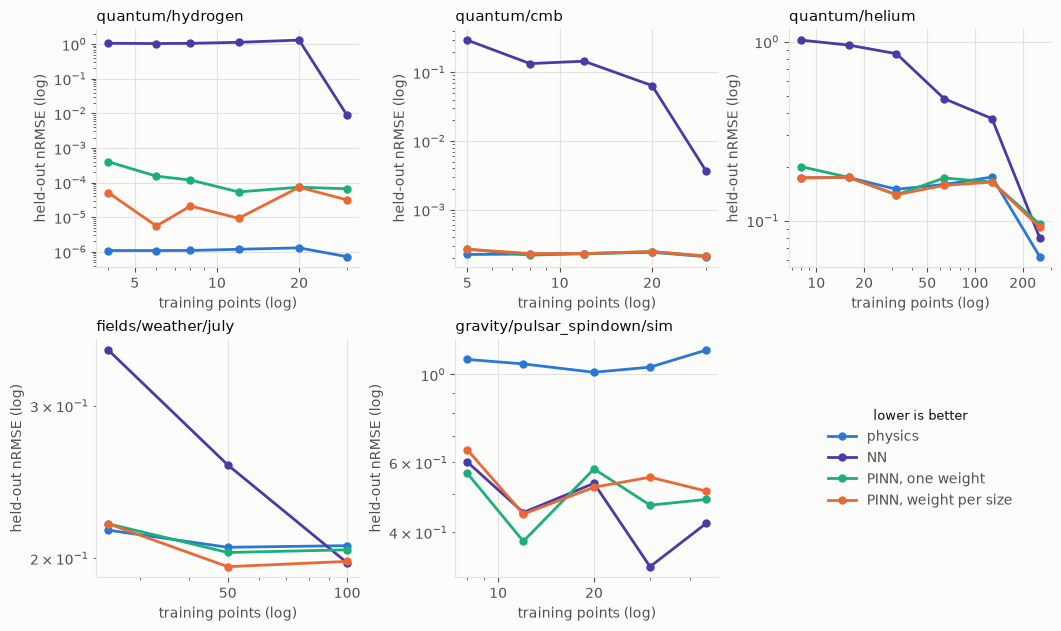

In [33]:
S.budget_result();

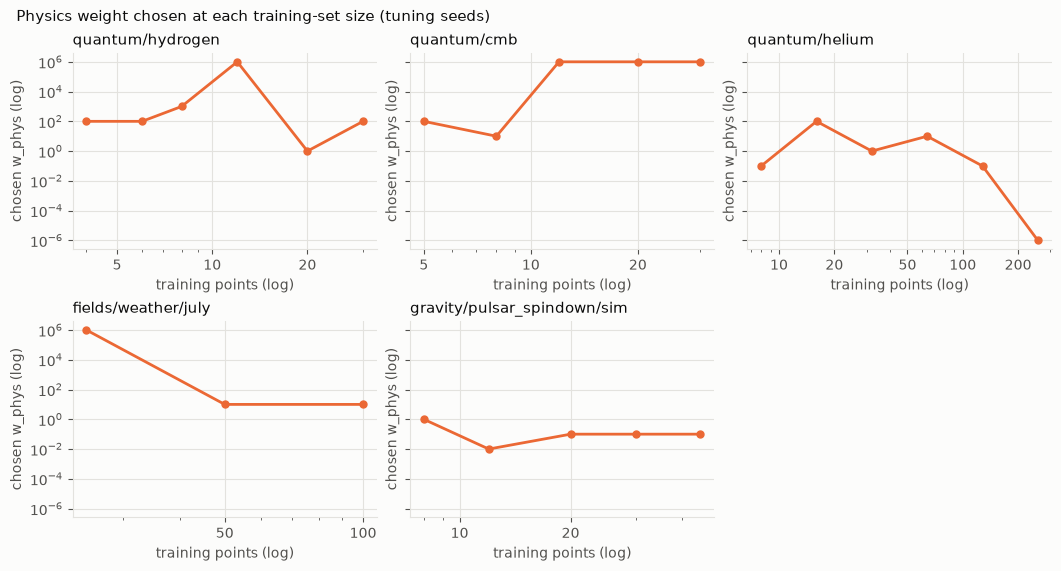

In [34]:
S.budget_weight_result();

In [35]:
print(S.budget_conclusion())

Weight per size is no worse than the single weight in 17/25 (track, size) cells and beats physics in 10/25; the weight at the smallest size is at least that at the largest on 4/5 tracks. H7 by its pre-registered criterion: not refuted.


## In progress

- **Helium.** With its tuned weight, the PINN extrapolates worse than the
  fitted hydrogenic law, so H3 is refuted there
  ([quantum](../docs/quantum/README.md#the-real-data-track-quantumhelium)).
- **Algebraic tracks with the tuned PINN.** With the correction active, it
  extrapolates worse than the fitted law
  ([DECISIONS.md](../docs/DECISIONS.md), [optimization §5](../docs/optimization/README.md)).
- **Helmholtz-residual PINN on the radio field.** The receivers record no phase,
  so the residual leaves the field under-determined
  ([rf](../docs/fields/rf.md#shape-a-a-helmholtz-residual-pinn-on-a-window)).
- **3-D PDE-residual PINN in reconstruction.** Run at two sensor counts per
  dimension with an untuned weight; in 3-D it is less accurate than a plain GP
  at the same count ([reconstruction](../docs/reconstruction/README.md)).